<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB04_KD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Chapter 8 — Attention Optimization
## NB04: Recovering Generation Capabilities

[![LinkedIn](https://img.shields.io/badge/LinkedIn-blue?logo=linkedin)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-black?logo=github)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?logo=x)](https://x.com/peraborges) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-yellow)](https://huggingface.co/oopere)

**Supplementary code for the [Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models) book by [Pere Martra](https://www.yourwebsite.com).**

**Code repository:** [https://github.com/peremartra/Rearchitecting-LLMs](https://github.com/peremartra/Rearchitecting-LLMs)

- **Author:** Pere Martra
- **Models:** `oopere/llama-3.2-3b-attn-drop-3`
- **Colab Environment:** A100 GPU
- **Keys:**
  - KV Cache
  - Attention Pruning
  - Knowledge Recovery
  - Knowledge Distillation
- **References:**
  - [Manning Book: Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models)
  - [Not All Attention is Needed](https://arxiv.org/abs/2406.15786)

This notebook restores the text generation capability of a model from which 3 attention layers have been removed.

The model was created in the notebook:[CH08_NB03_Remove_Attention_.ipynb](https://github.com/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB03_Remove_Attention_.ipynb)

**Model:** meta-llama/Llama-3.2-1B  
**Environment:** Google Colab A100.
**Library:** [OptipFair](https://github.com/peremartra/optipfair).

In [ ]:
!pip install --upgrade git+https://github.com/peremartra/optipfair.git
!pip install -q transformers==5.4.0
!pip install -q datasets tqdm matplotlib
!pip install -q lm-eval langdetect codecarbon
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

  Cloning https://github.com/peremartra/optipfair.git to /tmp/pip-req-build-5ojg_d7v
  Running command git clone --filter=blob:none --quiet https://github.com/peremartra/optipfair.git /tmp/pip-req-build-5ojg_d7v
  Resolved https://github.com/peremartra/optipfair.git to commit 9e8c9f0ecb7537346ca8d4a67efaad535b3a90b3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for optipfair: filename=optipfair-0.3.0-py3-none-any.whl size=65101 sha256=720c535a56e76915a1458be9b85aadeb93b7c447410b5b78505535049e4b53f8
  Stored in directory: /tmp/pip-ephem-wheel-cache-q7y7xmhr/wheels/34/ee/95/45c0e77756d6cde346debec33bab0826fe994bc1baeeda4f31
Successfully built optipfair
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 77.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 33.9 MB/s eta 0:00

## 1. Global Configuration

In [ ]:
# Models
TEACHER_MODEL_ID = "meta-llama/Llama-3.2-3B"
STUDENT_MODEL_ID = "oopere/llama-3.2-3b-attn-drop-3"

# Data and training
DATASET_NAME = "HuggingFaceTB/cosmopedia"
RECOVERY_SAMPLES = 10000
EPOCHS = 1
LEARNING_RATE = 2.5e-5
BATCH_SIZE = 8
MAX_LENGTH = 512
LAYERS_TO_REMOVE_COUNT = 10

# Distillation config
ALPHA = 0.6
BETA = 0.4
GAMMA = 0.00
DELTA = 0.00
TEMPERATURE = 2
SKEW_ALPHA = 0.3
SCHEDULER = "cosine"
WARMUP_RATIO = 0.15
ACCUMULATION_STEPS = 2
LAYER_MAPPING_STRATEGY = "last"

# lm_eval defaults
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa",
]
BENCHMARK_LIMIT = 400
LMEVAL_BATCH_SIZE = "auto"

SUBSETS = [
    ("stories", 0.300),
    ("web_samples_v2", 0.200),
    ("web_samples_v1", 0.150),
    ("wikihow", 0.150),
    ("openstax", 0.125),
    ("stanford", 0.075),
]

## 2. Imports and Setup

In [ ]:
import torch
import matplotlib.pyplot as plt
from copy import deepcopy
from datasets import Dataset, load_dataset
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import optipfair as opf
from utils import model_evaluation, get_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
assert abs(sum(w for _, w in SUBSETS) - 1.0) < 1e-6

Using device: cuda


In [ ]:
print(f"Loading teacher model: {TEACHER_MODEL_ID}")
teacher_model = AutoModelForCausalLM.from_pretrained(
    TEACHER_MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
teacher_model.eval()
for p in teacher_model.parameters():
    p.requires_grad = False

Loading teacher model: meta-llama/Llama-3.2-3B


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [ ]:
print(f"Loading student base model: {STUDENT_MODEL_ID}")
student_model = AutoModelForCausalLM.from_pretrained(
    STUDENT_MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Teacher layers: {teacher_model.config.num_hidden_layers}")
print(f"Student base layers: {student_model.config.num_hidden_layers}")

Loading student base model: oopere/llama-3.2-3b-attn-drop-3


config.json:   0%|          | 0.00/989 [00:00<?, ?B/s]

modeling_pruned_llama.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/oopere/llama-3.2-3b-attn-drop-3:
- modeling_pruned_llama.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Teacher layers: 28
Student base layers: 28


## 3. Prepare Recovery Dataset

In [ ]:
print("Loading Cosmopedia subsets...")
all_samples = []
for subset, weight in SUBSETS:
    n_samples = int(RECOVERY_SAMPLES * weight)
    subset_data = load_dataset(DATASET_NAME, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(n_samples))
    all_samples.extend(subset_samples)

distillation_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"Total samples: {len(distillation_dataset):,}")

texts = [item["text"] for item in distillation_dataset]
tokenized_batches = []
for i in tqdm(range(0, len(texts), 100), desc="Tokenizing"):
    batch = tokenizer(
        texts[i:i + 100],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    tokenized_batches.append(batch)

input_ids = torch.cat([b["input_ids"] for b in tokenized_batches], dim=0)
attention_mask = torch.cat([b["attention_mask"] for b in tokenized_batches], dim=0)
full_dataset = TensorDataset(input_ids, attention_mask)

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train: {len(train_dataset):,} samples ({len(train_dataloader):,} batches)")
print(f"Val: {len(val_dataset):,} samples")

Loading Cosmopedia subsets...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Total samples: 10,000


Tokenizing:   0%|          | 0/100 [00:00<?, ?it/s]

Train: 8,000 samples (1,000 batches)
Val: 2,000 samples


## 5. Knowledge Distillation

In [ ]:
student_to_train = deepcopy(student_model)

trained_student, stats = opf.distill_model(
    student_model=student_to_train,
    teacher_model=teacher_model,
    dataloader=train_dataloader,
    alpha=ALPHA,
    beta=BETA,
    epochs=EPOCHS,
    accumulation_steps=ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    show_progress=True,
    return_stats=True,
)

print("Training complete")
print(f"Total time: {stats['total_time_seconds']:.1f}s ({stats['total_time_seconds'] / 60:.1f} min)")
print(f"Final total loss: {stats['loss_history']['total'][-1]:.4f}")

Epoch 1/1:   0%|          | 0/1000 [00:00<?, ?it/s]

Training complete
Total time: 746.1s (12.4 min)
Final total loss: 0.9957


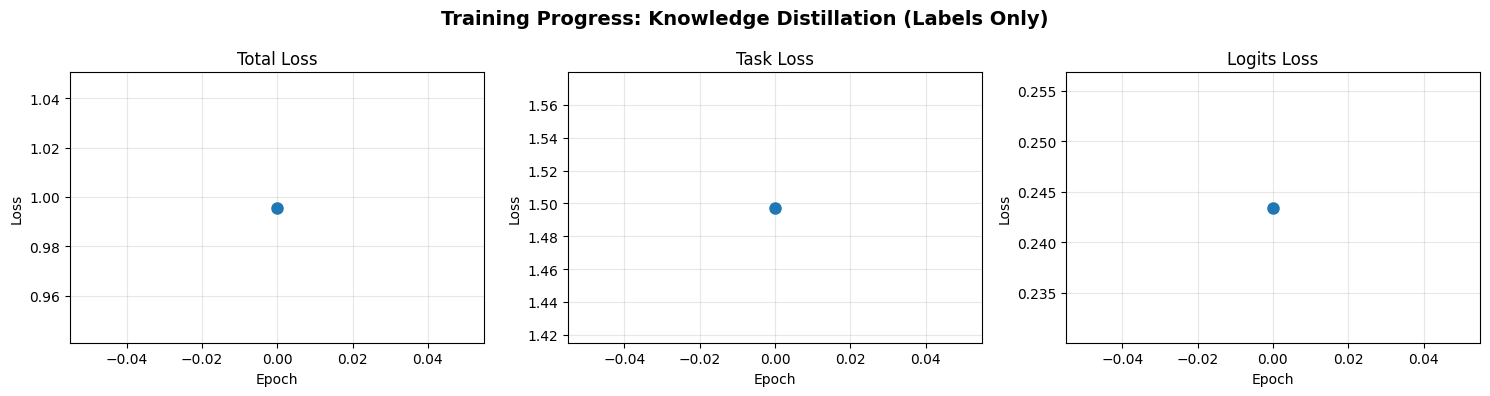

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
loss_keys = [("total", "Total Loss"), ("task", "Task Loss"), ("logits", "Logits Loss")]
for idx, (key, title) in enumerate(loss_keys):
    axes[idx].plot(stats['loss_history'][key], marker='o', linewidth=2, markersize=8)
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('Training Progress: Knowledge Distillation (Labels Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Final lm_eval Benchmarks

In [ ]:
trained_student.eval()
print("Running lm_eval benchmarks...")
print(f"Tasks: {BENCHMARK_TASKS}")
print(f"Rows per task (limit): {BENCHMARK_LIMIT}")
print(f"Batch size: {LMEVAL_BATCH_SIZE}")

student_bench_raw = model_evaluation(
    trained_student,
    tokenizer,
    BENCHMARK_TASKS,
    limit=BENCHMARK_LIMIT,
    device=str(device),
    batch_size=LMEVAL_BATCH_SIZE,
)

def extract_acc(results, task):
    r = results.get(task, {})
    for key in ("accuracy", "acc_norm", "acc"):
        if key in r:
            return float(r[key]) * 100
    return 0.0

student_scores = {task: extract_acc(student_bench_raw, task) for task in BENCHMARK_TASKS}

print("\nBenchmark results (student):")
print(f"{'Task':<20} {'Score':>10}")
print('-' * 32)
for task in BENCHMARK_TASKS:
    print(f"{task:<20} {student_scores[task]:>9.1f}%")

avg_student = sum(student_scores.values()) / len(student_scores)
print('-' * 32)
print(f"{'AVERAGE':<20} {avg_student:>9.1f}%")

Running lm_eval benchmarks...
Tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']
Rows per task (limit): 400
Batch size: auto
Starting lm-eval on model 'oopere/llama-3.2-3b-attn-drop-3' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (limit=400)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 5198/5198 [02:45<00:00, 31.32it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 159.38it/s]



Benchmark results (student):
Task                      Score
--------------------------------
arc_easy                  75.5%
winogrande                70.0%
hellaswag                 48.5%
lambada_openai            64.2%
piqa                      76.2%
--------------------------------
AVERAGE                   66.9%


In [ ]:
student_bench_raw

{'arc_easy': {'accuracy': '0.7550', 'acc_norm': '0.7075'},
 'hellaswag': {'accuracy': '0.4850', 'acc_norm': '0.6425'},
 'lambada_openai': {'perplexity': '5.32', 'accuracy': '0.6425'},
 'piqa': {'accuracy': '0.7625', 'acc_norm': '0.7825'},
 'winogrande': {'accuracy': '0.7000'}}

{'arc_easy': {'accuracy': '0.7500', 'acc_norm': '0.6975'},
 'hellaswag': {'accuracy': '0.5000', 'acc_norm': '0.6525'},
 'lambada_openai': {'perplexity': '5.27', 'accuracy': '0.6425'},
 'piqa': {'accuracy': '0.7625', 'acc_norm': '0.7775'},
 'winogrande': {'accuracy': '0.6900'}}

In [ ]:
BASELINE_PROMPT = "Paris is the capital of"
output = get_output(trained_student, tokenizer, BASELINE_PROMPT)
print(f"Pruned model output:\n{output}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Pruned model output:
 France and the largest city in the country. It is located in the north-central part of the country, on the Seine River. The city is known for its rich history, culture, and architecture. The Eiffel Tower is one of the most famous landmarks in Paris and is a symbol of the city. The Louvre Museum is another popular attraction, housing some of the world's most famous paintings and sculptures. The Notre Dame Cathedral is another important religious site in Paris, and the Sacre
